In [1]:
!git clone https://github.com/jaykkim1/KNOC_KPA_2026.git /content/repo

Cloning into '/content/repo'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 41 (delta 17), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 1.41 MiB | 8.88 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [2]:
# 실습 데이터 업로드 & 압축 풀기
from google.colab import files
uploaded = files.upload()  # Day2_실습데이터.zip 선택해서 업로드

import zipfile, os
zip_name = list(uploaded.keys())[0]  # 실제 업로드된 파일명을 그대로 사용
                                       # (Colab이 이름을 바꿔 저장해도(예: "(1)") 안전하게 동작)
with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall(".")

print("압축 해제 완료:", os.listdir("."))

Saving Day2_실습데이터.zip to Day2_실습데이터.zip
압축 해제 완료: ['.config', 'repo', '실적_전체.xlsx', '직원명단.xlsx', 'Day2_실습데이터.zip', '실적', 'sample_data']


In [3]:
import pandas as pd

df = pd.read_excel("직원명단.xlsx")
df.head()

,사번,이름,부서,입사일,최근교육이수여부
0,1001,김민수,영업,2021-03,Y
1,1002,이서연,개발,2016-02,Y
2,1003,박지훈,인사,2021-10,NaN
3,1004,최하은,재무,2024-04,Y
4,1005,정도윤,마케팅,2017-07,Y


In [4]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   사번        20 non-null     int64 
 1   이름        20 non-null     object
 2   부서        18 non-null     object
 3   입사일       20 non-null     object
 4   최근교육이수여부  16 non-null     object
dtypes: int64(1), object(4)
memory usage: 932.0+ bytes


In [5]:
df

,사번,이름,부서,입사일,최근교육이수여부
0,1001,김민수,영업,2021-03,Y
1,1002,이서연,개발,2016-02,Y
2,1003,박지훈,인사,2021-10,NaN
3,1004,최하은,재무,2024-04,Y
4,1005,정도윤,마케팅,2017-07,Y
5,1006,강예은,영업,2017-04,Y
6,1007,조성민,개발,2024-07,Y
7,1008,윤수아,인사,2017-04,Y
8,1009,장재현,재무,2022-01,N
9,1010,임지우,마케팅,2016-09,NaN


In [6]:
df.describe()

,사번
count,20.00000
mean,1010.50000
std,5.91608
min,1001.00000
25%,1005.75000
50%,1010.50000
75%,1015.25000
max,1020.00000


In [7]:
# 열 만들기
df['입사연도'] = df['입사일'].str[:4]
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   사번        20 non-null     int64 
 1   이름        20 non-null     object
 2   부서        18 non-null     object
 3   입사일       20 non-null     object
 4   최근교육이수여부  16 non-null     object
 5   입사연도      20 non-null     object
dtypes: int64(1), object(5)
memory usage: 1.1+ KB


In [8]:
# 입사연도로 필터 걸기
# df[df['입사연도']>=2020]
df['입사연도'] = pd.to_numeric(df['입사연도'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   사번        20 non-null     int64 
 1   이름        20 non-null     object
 2   부서        18 non-null     object
 3   입사일       20 non-null     object
 4   최근교육이수여부  16 non-null     object
 5   입사연도      20 non-null     int64 
dtypes: int64(2), object(4)
memory usage: 1.1+ KB


In [9]:
df[df['입사연도']>=2020]

,사번,이름,부서,입사일,최근교육이수여부,입사연도
0,1001,김민수,영업,2021-03,Y,2021
2,1003,박지훈,인사,2021-10,NaN,2021
3,1004,최하은,재무,2024-04,Y,2024
6,1007,조성민,개발,2024-07,Y,2024
8,1009,장재현,재무,2022-01,N,2022
10,1011,김우진,영업,2020-07,N,2020
11,1012,이다은,개발,2024-02,N,2024
12,1013,박현우,인사,2024-11,N,2024
14,1015,정준서,마케팅,2021-02,Y,2021
16,1017,조시우,개발,2023-11,NaN,2023


In [10]:
# 입사연도 오름차순으로 정리

df_year_sorted = df.sort_values('입사연도') # 내림차순하려면 , ascending = False
df_year_sorted

,사번,이름,부서,입사일,최근교육이수여부,입사연도
1,1002,이서연,개발,2016-02,Y,2016
9,1010,임지우,마케팅,2016-09,NaN,2016
15,1016,강채원,영업,2016-10,N,2016
7,1008,윤수아,인사,2017-04,Y,2017
5,1006,강예은,영업,2017-04,Y,2017
13,1014,최소율,재무,2017-10,N,2017
4,1005,정도윤,마케팅,2017-07,Y,2017
19,1020,임지민,NaN,2018-12,N,2018
10,1011,김우진,영업,2020-07,N,2020
14,1015,정준서,마케팅,2021-02,Y,2021


In [11]:

df_year_sorted = df.sort_values('입사연도').reset_index(drop=True) # 내림차순하려면 , ascending = False
df_year_sorted

,사번,이름,부서,입사일,최근교육이수여부,입사연도
0,1002,이서연,개발,2016-02,Y,2016
1,1010,임지우,마케팅,2016-09,NaN,2016
2,1016,강채원,영업,2016-10,N,2016
3,1008,윤수아,인사,2017-04,Y,2017
4,1006,강예은,영업,2017-04,Y,2017
5,1014,최소율,재무,2017-10,N,2017
6,1005,정도윤,마케팅,2017-07,Y,2017
7,1020,임지민,NaN,2018-12,N,2018
8,1011,김우진,영업,2020-07,N,2020
9,1015,정준서,마케팅,2021-02,Y,2021


In [12]:
# 특정 열만 추출

df_filtered = df[['사번', '이름', '입사일']]
df_filtered

,사번,이름,입사일
0,1001,김민수,2021-03
1,1002,이서연,2016-02
2,1003,박지훈,2021-10
3,1004,최하은,2024-04
4,1005,정도윤,2017-07
5,1006,강예은,2017-04
6,1007,조성민,2024-07
7,1008,윤수아,2017-04
8,1009,장재현,2022-01
9,1010,임지우,2016-09


In [13]:
# 부서명 종류 보기

print('부서명: ', df['부서'].unique())
print('부서개수(누락팀 포함): ',len(df['부서'].unique()))

부서명:  ['영업' '개발' '인사' '재무' '마케팅' nan]
부서개수(누락팀 포함):  6


In [14]:
df.describe()

,사번,입사연도
count,20.00000,20.000000
mean,1010.50000,2020.000000
std,5.91608,2.991215
min,1001.00000,2016.000000
25%,1005.75000,2017.000000
50%,1010.50000,2021.000000
75%,1015.25000,2022.250000
max,1020.00000,2024.000000


In [15]:
df

,사번,이름,부서,입사일,최근교육이수여부,입사연도
0,1001,김민수,영업,2021-03,Y,2021
1,1002,이서연,개발,2016-02,Y,2016
2,1003,박지훈,인사,2021-10,NaN,2021
3,1004,최하은,재무,2024-04,Y,2024
4,1005,정도윤,마케팅,2017-07,Y,2017
5,1006,강예은,영업,2017-04,Y,2017
6,1007,조성민,개발,2024-07,Y,2024
7,1008,윤수아,인사,2017-04,Y,2017
8,1009,장재현,재무,2022-01,N,2022
9,1010,임지우,마케팅,2016-09,NaN,2016


In [16]:
# 인사정보 for문으로 도시하기, + f-string 활용

이름 = 1
부서 = 2
입사연도 = 5

for i in range(0, len(df)):
  name = df.iloc[i, 이름]
  team = df.iloc[i, 부서]
  year = df.iloc[i, 입사연도]

  if pd.isna(team):
    team = "정보가 확인되지 않는"

  print(f"{name}씨는 {team}팀에 근무하며, 입사연도는 {year}년 입니다.")

김민수씨는 영업팀에 근무하며, 입사연도는 2021년 입니다.
이서연씨는 개발팀에 근무하며, 입사연도는 2016년 입니다.
박지훈씨는 인사팀에 근무하며, 입사연도는 2021년 입니다.
최하은씨는 재무팀에 근무하며, 입사연도는 2024년 입니다.
정도윤씨는 마케팅팀에 근무하며, 입사연도는 2017년 입니다.
강예은씨는 영업팀에 근무하며, 입사연도는 2017년 입니다.
조성민씨는 개발팀에 근무하며, 입사연도는 2024년 입니다.
윤수아씨는 인사팀에 근무하며, 입사연도는 2017년 입니다.
장재현씨는 재무팀에 근무하며, 입사연도는 2022년 입니다.
임지우씨는 마케팅팀에 근무하며, 입사연도는 2016년 입니다.
김우진씨는 영업팀에 근무하며, 입사연도는 2020년 입니다.
이다은씨는 개발팀에 근무하며, 입사연도는 2024년 입니다.
박현우씨는 인사팀에 근무하며, 입사연도는 2024년 입니다.
최소율씨는 재무팀에 근무하며, 입사연도는 2017년 입니다.
정준서씨는 마케팅팀에 근무하며, 입사연도는 2021년 입니다.
강채원씨는 영업팀에 근무하며, 입사연도는 2016년 입니다.
조시우씨는 개발팀에 근무하며, 입사연도는 2023년 입니다.
윤예린씨는 정보가 확인되지 않는팀에 근무하며, 입사연도는 2021년 입니다.
장동현씨는 재무팀에 근무하며, 입사연도는 2021년 입니다.
임지민씨는 정보가 확인되지 않는팀에 근무하며, 입사연도는 2018년 입니다.


In [17]:
# 필터 1개 걸어서 엑셀파일로 저장

df_sorted = df[df['입사연도'] >=2020]
df_sorted

,사번,이름,부서,입사일,최근교육이수여부,입사연도
0,1001,김민수,영업,2021-03,Y,2021
2,1003,박지훈,인사,2021-10,NaN,2021
3,1004,최하은,재무,2024-04,Y,2024
6,1007,조성민,개발,2024-07,Y,2024
8,1009,장재현,재무,2022-01,N,2022
10,1011,김우진,영업,2020-07,N,2020
11,1012,이다은,개발,2024-02,N,2024
12,1013,박현우,인사,2024-11,N,2024
14,1015,정준서,마케팅,2021-02,Y,2021
16,1017,조시우,개발,2023-11,NaN,2023


In [18]:
# 필터 2개 걸어서 엑셀파일로 저장
df_sorted_2 = df[(df['입사연도'] >=2020) & (df['부서'] == '영업')]
df_sorted_2

,사번,이름,부서,입사일,최근교육이수여부,입사연도
0,1001,김민수,영업,2021-03,Y,2021
10,1011,김우진,영업,2020-07,N,2020


In [19]:
df_sorted_2 = df[df['입사연도'] >=2020][df['부서'] == '영업']
df_sorted_2

/tmp/ipykernel_2965/2979316580.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_sorted_2 = df[df['입사연도'] >=2020][df['부서'] == '영업']


,사번,이름,부서,입사일,최근교육이수여부,입사연도
0,1001,김민수,영업,2021-03,Y,2021
10,1011,김우진,영업,2020-07,N,2020


In [20]:
df_sorted_2 = df[(df['입사연도'] >=2020) | (df['부서'] == '영업')] # or
df_sorted_2

,사번,이름,부서,입사일,최근교육이수여부,입사연도
0,1001,김민수,영업,2021-03,Y,2021
2,1003,박지훈,인사,2021-10,NaN,2021
3,1004,최하은,재무,2024-04,Y,2024
5,1006,강예은,영업,2017-04,Y,2017
6,1007,조성민,개발,2024-07,Y,2024
8,1009,장재현,재무,2022-01,N,2022
10,1011,김우진,영업,2020-07,N,2020
11,1012,이다은,개발,2024-02,N,2024
12,1013,박현우,인사,2024-11,N,2024
14,1015,정준서,마케팅,2021-02,Y,2021


In [21]:
df_sorted_2.to_excel('filtered_data.xlsx', index=True)


In [22]:
df['입사연도'] >=2020

,입사연도
0,True
1,False
2,True
3,True
4,False
5,False
6,True
7,False
8,True
9,False


In [23]:
# 인사정보 for문으로 도시하기, + f-string 활용

이름 = "이름"
부서 = '부서'
입사연도 = '입사연도'

for i in range(0, len(df)):
  name = df.loc[i, 이름]
  team = df.loc[i, 부서]
  year = df.loc[i, 입사연도]
  print(f"{name}씨는 {team}팀에 근무하며, 입사연도는 {year}년 입니다.")

김민수씨는 영업팀에 근무하며, 입사연도는 2021년 입니다.
이서연씨는 개발팀에 근무하며, 입사연도는 2016년 입니다.
박지훈씨는 인사팀에 근무하며, 입사연도는 2021년 입니다.
최하은씨는 재무팀에 근무하며, 입사연도는 2024년 입니다.
정도윤씨는 마케팅팀에 근무하며, 입사연도는 2017년 입니다.
강예은씨는 영업팀에 근무하며, 입사연도는 2017년 입니다.
조성민씨는 개발팀에 근무하며, 입사연도는 2024년 입니다.
윤수아씨는 인사팀에 근무하며, 입사연도는 2017년 입니다.
장재현씨는 재무팀에 근무하며, 입사연도는 2022년 입니다.
임지우씨는 마케팅팀에 근무하며, 입사연도는 2016년 입니다.
김우진씨는 영업팀에 근무하며, 입사연도는 2020년 입니다.
이다은씨는 개발팀에 근무하며, 입사연도는 2024년 입니다.
박현우씨는 인사팀에 근무하며, 입사연도는 2024년 입니다.
최소율씨는 재무팀에 근무하며, 입사연도는 2017년 입니다.
정준서씨는 마케팅팀에 근무하며, 입사연도는 2021년 입니다.
강채원씨는 영업팀에 근무하며, 입사연도는 2016년 입니다.
조시우씨는 개발팀에 근무하며, 입사연도는 2023년 입니다.
윤예린씨는 nan팀에 근무하며, 입사연도는 2021년 입니다.
장동현씨는 재무팀에 근무하며, 입사연도는 2021년 입니다.
임지민씨는 nan팀에 근무하며, 입사연도는 2018년 입니다.


# 결측치 처리

In [24]:
df.isna()

pd.isna(df)

,사번,이름,부서,입사일,최근교육이수여부,입사연도
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,True,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
5,False,False,False,False,False,False
6,False,False,False,False,False,False
7,False,False,False,False,False,False
8,False,False,False,False,False,False
9,False,False,False,False,True,False


In [25]:
df.notna()

,사번,이름,부서,입사일,최근교육이수여부,입사연도
0,True,True,True,True,True,True
1,True,True,True,True,True,True
2,True,True,True,True,False,True
3,True,True,True,True,True,True
4,True,True,True,True,True,True
5,True,True,True,True,True,True
6,True,True,True,True,True,True
7,True,True,True,True,True,True
8,True,True,True,True,True,True
9,True,True,True,True,False,True


In [26]:
df.isna().sum()

,0
사번,0
이름,0
부서,2
입사일,0
최근교육이수여부,4
입사연도,0


# 결측치 제거

In [27]:
df_dropped = df.dropna()
df_dropped
df

,사번,이름,부서,입사일,최근교육이수여부,입사연도
0,1001,김민수,영업,2021-03,Y,2021
1,1002,이서연,개발,2016-02,Y,2016
2,1003,박지훈,인사,2021-10,NaN,2021
3,1004,최하은,재무,2024-04,Y,2024
4,1005,정도윤,마케팅,2017-07,Y,2017
5,1006,강예은,영업,2017-04,Y,2017
6,1007,조성민,개발,2024-07,Y,2024
7,1008,윤수아,인사,2017-04,Y,2017
8,1009,장재현,재무,2022-01,N,2022
9,1010,임지우,마케팅,2016-09,NaN,2016


In [28]:
len(df_dropped) # 행의 갯수 확인
df_dropped.shape[0] # 행의 갯수 확인

14

In [29]:
print('이상치 제거전의 행 개수:', len(df), '\n이상치 제거후:', len(df_dropped))

이상치 제거전의 행 개수: 20 
이상치 제거후: 14


In [30]:
# 누락 정보 채우기

df['최근교육이수여부_rev'] = df['최근교육이수여부'].fillna("N")
df.isna().sum()

,0
사번,0
이름,0
부서,2
입사일,0
최근교육이수여부,4
입사연도,0
최근교육이수여부_rev,0


# **피벗테이블 만들기**

In [31]:
df = pd.read_excel("실적_전체.xlsx")

df.head()
df.shape

(60, 5)

In [32]:
df

,지점명,담당자,판매건수,매출액,월
0,서울점,김O,17,6760203,1월
1,부산점,이O,21,6282969,1월
2,대구점,박O,23,9526600,1월
3,인천점,최O,33,10667019,1월
4,광주점,정O,44,16265348,1월
5,서울점,김O,15,6122670,2월
6,부산점,이O,24,6966648,2월
7,대구점,박O,33,9911451,2월
8,인천점,최O,40,14489880,2월
9,광주점,정O,38,14128286,2월


In [33]:
df.isna().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   지점명     60 non-null     object
 1   담당자     60 non-null     object
 2   판매건수    60 non-null     int64 
 3   매출액     60 non-null     int64 
 4   월       60 non-null     object
dtypes: int64(2), object(3)
memory usage: 2.5+ KB


In [34]:
# groupby

df['지점명'].unique()

grouped = df.groupby("지점명")
grouped.groups.keys()

dict_keys(['광주점', '대구점', '부산점', '서울점', '인천점'])

In [35]:
grouped["매출액"].sum()
df.groupby("지점명")["매출액"].sum()
df.groupby("지점명")["매출액"].mean()

,매출액
지점명,
광주점,1.263246e+07
대구점,9.124556e+06
부산점,8.522185e+06
서울점,5.981784e+06
인천점,1.163730e+07


In [36]:
df.groupby("지점명").size()

,0
지점명,
광주점,12
대구점,12
부산점,12
서울점,12
인천점,12


In [37]:
df[df['지점명'] == '광주점']['매출액'].mean()

np.float64(12632458.166666666)

In [38]:
df = pd.read_excel("직원명단.xlsx")

영업 = df[df['부서'] == '영업']
영업

,사번,이름,부서,입사일,최근교육이수여부
0,1001,김민수,영업,2021-03,Y
5,1006,강예은,영업,2017-04,Y
10,1011,김우진,영업,2020-07,N
15,1016,강채원,영업,2016-10,N


In [39]:
df.columns

Index(['사번', '이름', '부서', '입사일', '최근교육이수여부'], dtype='object')

In [40]:
영업.groupby("최근교육이수여부").size()

,0
최근교육이수여부,
N,2
Y,2


In [41]:
df

,사번,이름,부서,입사일,최근교육이수여부
0,1001,김민수,영업,2021-03,Y
1,1002,이서연,개발,2016-02,Y
2,1003,박지훈,인사,2021-10,NaN
3,1004,최하은,재무,2024-04,Y
4,1005,정도윤,마케팅,2017-07,Y
5,1006,강예은,영업,2017-04,Y
6,1007,조성민,개발,2024-07,Y
7,1008,윤수아,인사,2017-04,Y
8,1009,장재현,재무,2022-01,N
9,1010,임지우,마케팅,2016-09,NaN


In [42]:
df.groupby('부서').size()

,0
부서,
개발,4
마케팅,3
영업,4
인사,3
재무,4


In [43]:
df.groupby(['부서', '최근교육이수여부']).size()

부서   최근교육이수여부
개발   N           1
     Y           2
마케팅  Y           2
영업   N           2
     Y           2
인사   N           1
     Y           1
재무   N           2
     Y           1
dtype: int64

In [44]:
df['입사연도'] = df['입사일'].str[:4]
df.groupby('입사연도').size()

,0
입사연도,
2016,3
2017,4
2018,1
2020,1
2021,5
2022,1
2023,1
2024,4


In [45]:
score = [80,85,90,75,95]

sum(score)
len(score)
sum(score)/len(score)


85.0

In [46]:
import numpy as np

score = np.array(score)
score

np.average(score)
np.std(score)
np.var(score)

np.float64(50.0)

In [47]:
import pandas as pd

df_score = pd.DataFrame(score)
df_score.std()
df_score.mean()
df_score.min()

,0
0,75


In [48]:
df = pd.read_excel("실적_전체.xlsx")
round(df['매출액'].mean())


9579656

In [49]:
df.describe()

,판매건수,매출액
count,60.000000,6.000000e+01
mean,27.433333,9.579656e+06
std,7.812130,2.801819e+06
min,11.000000,3.500068e+06
25%,22.750000,7.337344e+06
50%,27.000000,9.539638e+06
75%,33.000000,1.137392e+07
max,44.000000,1.626535e+07


In [50]:
df.groupby("지점명")["매출액"].agg(["mean", "std"])

,mean,std
지점명,,
광주점,1.263246e+07,1.922718e+06
대구점,9.124556e+06,1.167144e+06
부산점,8.522185e+06,1.517846e+06
서울점,5.981784e+06,1.354056e+06
인천점,1.163730e+07,1.598818e+06


In [51]:
    # "count",   # 데이터 개수
    # "sum",     # 합계
    # "mean",    # 평균
    # "median",  # 중앙값
    # "min",     # 최솟값
    # "max",     # 최댓값
    # "var",     # 분산
    # "std"      # 표준편차

In [52]:
df[['판매건수', '매출액']].corr()

,판매건수,매출액
판매건수,1.00000,0.91924
매출액,0.91924,1.00000


In [53]:
df['월_숫자'] = df['월'].str[:-1].astype(int)
df['월_숫자'] = df['월'].str[:-1].astype(int)
df['월_숫자2'] = pd.to_numeric(df['월'].str[:-1])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   지점명     60 non-null     object
 1   담당자     60 non-null     object
 2   판매건수    60 non-null     int64 
 3   매출액     60 non-null     int64 
 4   월       60 non-null     object
 5   월_숫자    60 non-null     int64 
 6   월_숫자2   60 non-null     int64 
dtypes: int64(4), object(3)
memory usage: 3.4+ KB


In [54]:
df[['월_숫자', '매출액']].corr()

,월_숫자,매출액
월_숫자,1.000000,-0.135531
매출액,-0.135531,1.000000


# **그래프 그리기**

In [55]:
import matplotlib.pyplot as plt

x = [1,2,3,4,5]
y = [10,20,30,40,50]
y2 = [5, 15, 25, 35, 450]

In [56]:
# 한글 폰트 설정 (그래프에 한글이 깨져 보이는 문제 방지)
!apt-get -qq install -y fonts-nanum > /dev/null

import matplotlib.font_manager as fm
fontpath = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(fontpath)
plt.rc("font", family=fm.FontProperties(fname=fontpath).get_name())
plt.rcParams["axes.unicode_minus"] = False
# ※ 그래프에 한글이 여전히 깨져 보이면, 런타임을 재시작한 뒤 이 셀부터 다시 실행하세요

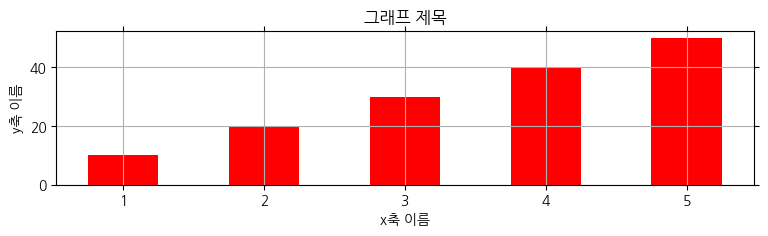

In [57]:
# 1. bargraph
plt.figure(figsize=(9,2))
plt.title("그래프 제목")
plt.bar(x, y, color='red', width=0.5)
plt.xlabel("x축 이름")
plt.ylabel("y축 이름")
plt.grid()
plt.tick_params(axis = 'both' , direction= 'out', top= True, right = True)
plt.savefig("bar graph.png", dpi=300)
plt.show()

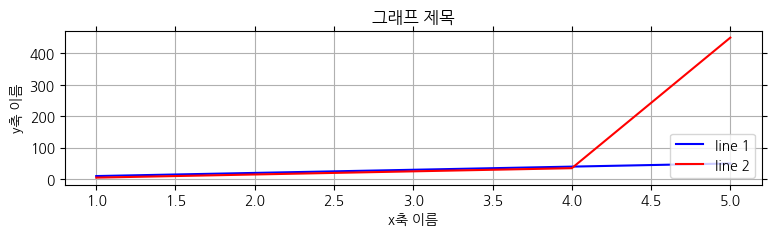

In [58]:
# 선 그래프
plt.figure(figsize=(9,2))
plt.title("그래프 제목")
plt.plot(x, y, color = 'blue', label = 'line 1')
plt.plot(x, y2, color = 'red', label = 'line 2')
plt.legend(loc = "lower right")
plt.grid()
plt.xlabel("x축 이름")
plt.ylabel("y축 이름")
plt.tick_params(axis = 'both' , direction= 'out', top= True, right = True)
plt.show()

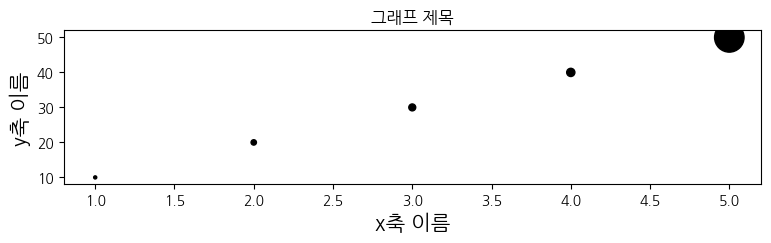

In [59]:
# 산점도: scatter plot
plt.figure(figsize=(9,2))
plt.title("그래프 제목")
plt.scatter(x,y, s = y2, color = "black")
plt.xlabel("x축 이름", fontsize= 15)
plt.ylabel("y축 이름", fontsize= 15)
plt.show()

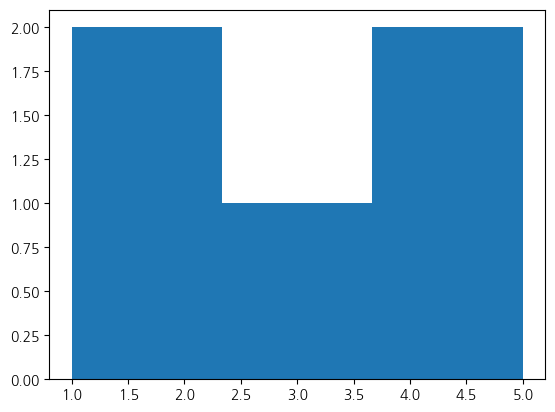

In [60]:
# 히스토그림
plt.hist(x, bins=3)
plt.show()

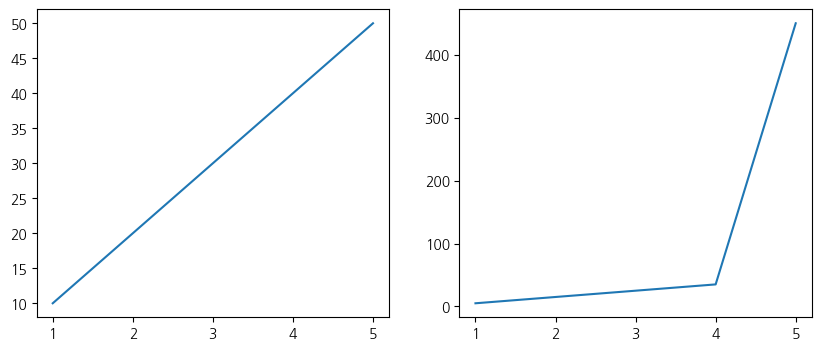

In [61]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(x,y)
ax[1].plot(x,y2)

plt.show()

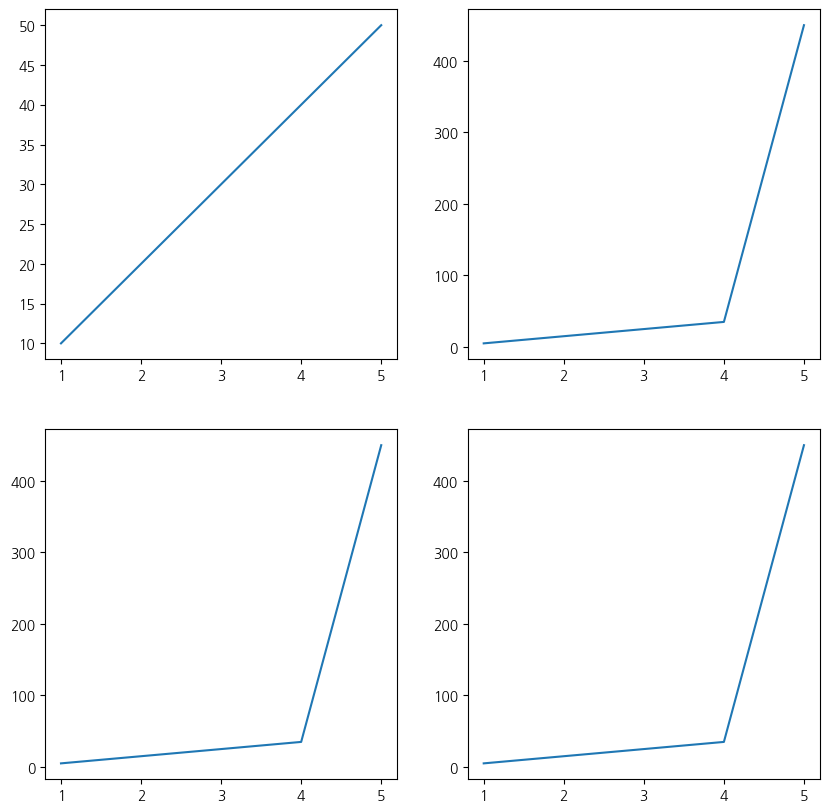

In [62]:
fig, ax = plt.subplots(2,2, figsize=(10,10))
ax[0,0].plot(x,y)
ax[0,1].plot(x,y2)
ax[1,0].plot(x,y2)
ax[1,1].plot(x,y2)
plt.show()

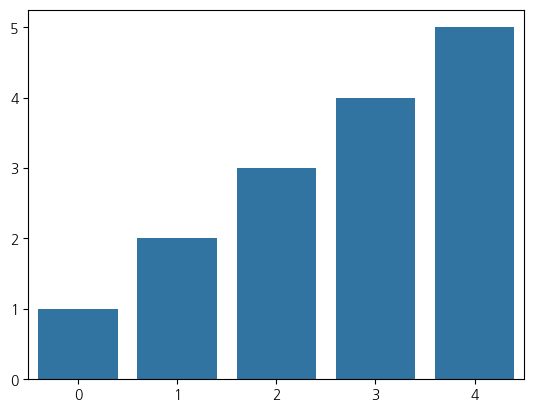

In [63]:
# seaborn을 사용한 그래프
import seaborn as sns

sns.barplot(data= x)
plt.show()


In [64]:
월별 = df.groupby("월", sort = False)["매출액"].sum().reset_index()
월별

,월,매출액
0,1월,49502139
1,2월,51618935
2,3월,49497643
3,4월,51516223
4,5월,46172959
5,6월,46831317
6,7월,48551998
7,8월,49251878
8,9월,46085078
9,10월,48367842


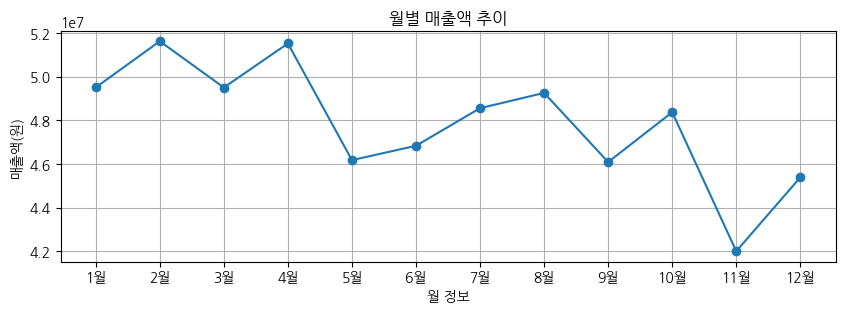

In [65]:
plt.figure(figsize=(10,3))
plt.plot(월별['월'], 월별['매출액'], marker = 'o')
plt.xlabel('월 정보')
plt.ylabel('매출액(원)')
plt.title("월별 매출액 추이")
plt.grid()
plt.show()

In [66]:
# df에서 지점별 매출액 합산 구하고 bar plot

df_location = df.groupby("지점명")["매출액"].sum().reset_index()
df_location

,지점명,매출액
0,광주점,151589498
1,대구점,109494670
2,부산점,102266215
3,서울점,71781409
4,인천점,139647561


Text(0.5, 1.0, '지점별 매출 합계')

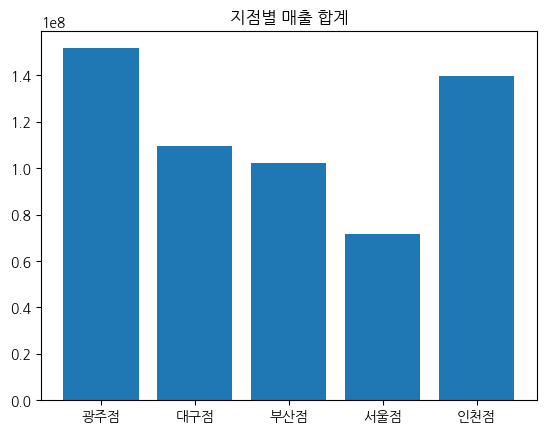

In [67]:
요약 = df.groupby("지점명")["매출액"].sum().reset_index()
plt.bar(요약["지점명"], 요약["매출액"])
plt.title("지점별 매출 합계")

NameError: name '지점별_매출합계_평균' is not defined

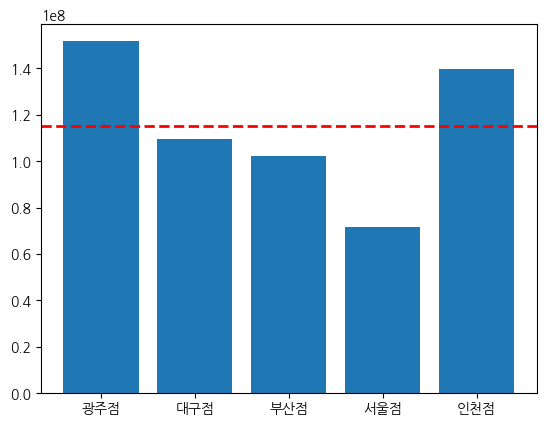

In [69]:
요약 = df.groupby("지점명")["매출액"].sum().reset_index()

# 지점별 평균 매출액의 전체 평균
전체평균 = 요약["매출액"].mean()
plt.bar(요약["지점명"], 요약["매출액"])

# 전체 평균을 빨간색 선으로 표시
plt.axhline(전체평균, color="red", linestyle="--", linewidth=2)
plt.text(len(요약) - 0.5, 지점별_매출합계_평균 * 1.05, f'평균: {지점별_매출합계_평균:,.0f}원', color='red', ha='right', va='bottom', fontsize=12, weight='bold')


plt.title("지점별 매출 합계")
plt.show()

In [ ]:
요약 = df.groupby("지점명")["매출액"].sum().reset_index()

plt.figure(figsize=(10, 6)) # 그래프 크기 설정
plt.bar(요약["지점명"], 요약["매출액"])
plt.title("지점별 매출 합계")
plt.xlabel("지점")
plt.ylabel("매출액(원)")

# 각 지점별 매출 합계의 평균 계산
지점별_매출합계_평균 = 요약["매출액"].mean()

# 평균선 추가 (빨간색, 굵게)
plt.axhline(지점별_매출합계_평균, color='red', linestyle='-', linewidth=3, label=f'지점별 매출합계 평균: {지점별_매출합계_평균:,.0f}원')

# 평균값 텍스트로 표기 (선 위에 표시)
# x축 위치는 막대그래프의 중간 정도, y축 위치는 평균선 위쪽으로 조정
plt.text(len(요약) - 0.5, 지점별_매출합계_평균 * 1.05, f'평균: {지점별_매출합계_평균:,.0f}원', color='red', ha='right', va='bottom', fontsize=12, weight='bold')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7) # 그리드 라인 추가
plt.tight_layout() # 레이아웃 자동 조정
plt.show()

In [ ]:
test= df.groupby("지점명")["매출액"].sum().reset_index()
test['매출액'].mean()

In [ ]:
df["매출액"].sum()/len(df['지점명'].unique())

바이브 코딩

In [ ]:
!pip install gradio requests

In [ ]:
import gradio as gr
import requests

def get_weather(city_name):
    # 1. 도시 이름을 위도/경도로 변환 (Open-Meteo Geocoding API)
    geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={city_name}&count=1&language=en&format=json"

    try:
        geo_res = requests.get(geo_url).json()
        if "results" not in geo_res or not geo_res["results"]:
            return f"❌ '{city_name}'에 해당하는 도시를 찾을 수 없습니다. 올바른 영문 도시명(예: Seoul, New York, Tokyo)을 입력해주세요."

        location = geo_res["results"][0]
        lat = location["latitude"]
        lon = location["longitude"]
        country = location.get("country", "")
        name = location.get("name", city_name)

        # 2. 해당 좌표의 실시간 날씨 정보 조회 (Open-Meteo Weather API)
        weather_url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current=temperature_2m,relative_humidity_2m,apparent_temperature,wind_speed_10m"
        weather_res = requests.get(weather_url).json()

        current = weather_res["current"]
        temp = current["temperature_2m"]
        apparent_temp = current["apparent_temperature"]
        humidity = current["relative_humidity_2m"]
        wind_speed = current["wind_speed_10m"]

        # 3. 보기 좋게 결과 포맷팅
        result_text = f"""
        🌍 **위치:** {name}, {country} (위도: {lat}, 경도: {lon})

        🌡️️ **현재 기온:** {temp} °C
         відчутие (체감 기온): {apparent_temp} °C
         💧 **습도:** {humidity} %
         🌬️ **풍속:** {wind_speed} m/s
        """
        return result_text

    except Exception as e:
        return f"⚠️ 데이터를 불러오는 중 오류가 발생했습니다: {str(e)}"

# Gradio 인터페이스 구성
demo = gr.Interface(
    fn=get_weather,
    inputs=gr.Textbox(label="도시 이름 (영문)", placeholder="예: Seoul, London, New York", value="Seoul"),
    outputs=gr.Markdown(label="실시간 날씨 정보"),
    title="🌦️ 실시간 날씨 확인 웹앱",
    description="도시 이름을 영문으로 입력하면 Open-Meteo API를 통해 실시간 날씨 정보를 가져옵니다."
)

# 코랩에서 실행할 때는 share=True를 주어야 외부 접속 가능한 링크가 생성됩니다.
demo.launch(share=True, debug=True)

In [ ]:
import gradio as gr
import requests

def get_weather(city_name):
    if not city_name.strip():
        return "❌ 도시 이름을 입력해주세요."

    # 1. 도시 이름을 위도/경도로 변환 (language=ko를 지정하여 한글 검색 지원)
    geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={city_name}&count=1&language=ko&format=json"

    try:
        geo_res = requests.get(geo_url).json()
        if "results" not in geo_res or not geo_res["results"]:
            return f"❌ '{city_name}'에 해당하는 도시를 찾을 수 없습니다. 올바른 도시명(예: 서울, 도쿄, 뉴욕)을 입력해주세요."

        location = geo_res["results"][0]
        lat = location["latitude"]
        lon = location["longitude"]
        country = location.get("country", "")
        name = location.get("name", city_name)

        # 2. 해당 좌표의 실시간 날씨 정보 조회
        weather_url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current=temperature_2m,relative_humidity_2m,apparent_temperature,wind_speed_10m"
        weather_res = requests.get(weather_url).json()

        current = weather_res["current"]
        temp = current["temperature_2m"]
        apparent_temp = current["apparent_temperature"]
        humidity = current["relative_humidity_2m"]
        wind_speed = current["wind_speed_10m"]

        # 3. 결과 포맷팅
        result_text = f"""
        ### 🌍 위치: {name} ({country})
        * **위도 / 경도:** {lat}, {lon}
        * **🌡️️ 현재 기온:** {temp} °C
        * **🧥 체감 기온:** {apparent_temp} °C
        * **💧 습도:** {humidity} %
        * **🌬️ 풍속:** {wind_speed} m/s
        """
        return result_text

    except Exception as e:
        return f"⚠️ 데이터를 불러오는 중 오류가 발생했습니다: {str(e)}"

# Gradio 인터페이스 구성
demo = gr.Interface(
    fn=get_weather,
    inputs=gr.Textbox(label="도시 이름", placeholder="예: 서울, 부산, 도쿄, 뉴욕", value="서울"),
    outputs=gr.Markdown(label="실시간 날씨 정보"),
    title="🌦️ 실시간 날씨 확인 웹앱 (한글 지원)",
    description="도시 이름을 한글(또는 영문)로 입력하면 실시간 날씨 정보를 가져옵니다."
)

# 코랩 실행용
demo.launch(share=True, debug=True)

In [97]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing


# ====================================
# 1. California Housing 데이터 불러오기
# ====================================

housing = fetch_california_housing(as_frame=True)
housing

{'data':        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
 1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
 2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
 3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
 4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
 ...       ...       ...       ...        ...         ...       ...       ...   
 20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
 20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
 20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
 20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
 20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   
 
        Longitude 

In [98]:
df = housing.frame
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [99]:



print(df.head())
print(df.columns)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


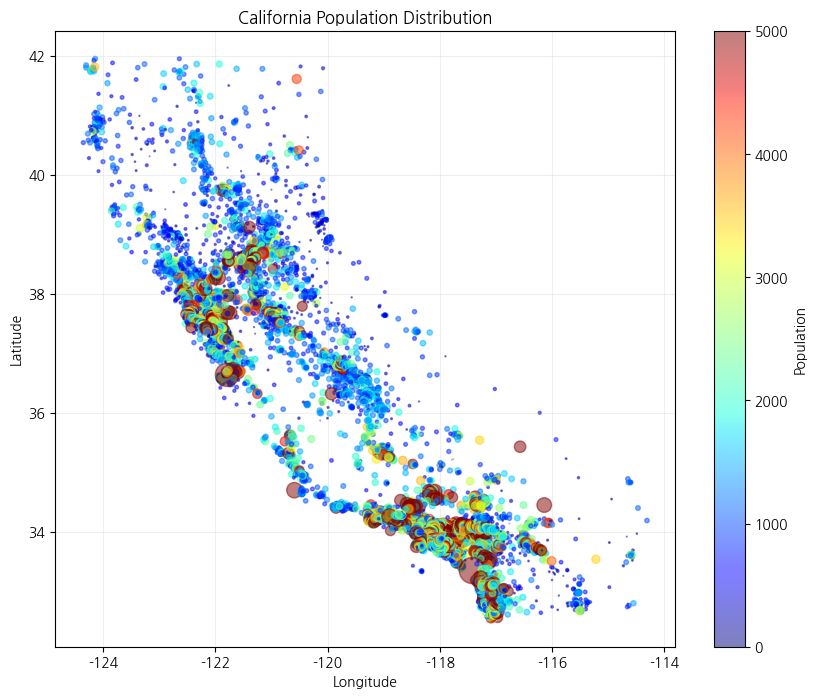

In [72]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["Population"],
    cmap="jet",
    s=df["Population"]/100,
    alpha=0.5,
    vmin= 0,
    vmax= 5000
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("California Population Distribution")

plt.colorbar(
    label="Population"
)

plt.grid(alpha=0.2)

plt.show()

Histogram & Boxplot

In [73]:
df = pd.read_excel("실적_전체.xlsx")
df

,지점명,담당자,판매건수,매출액,월
0,서울점,김O,17,6760203,1월
1,부산점,이O,21,6282969,1월
2,대구점,박O,23,9526600,1월
3,인천점,최O,33,10667019,1월
4,광주점,정O,44,16265348,1월
5,서울점,김O,15,6122670,2월
6,부산점,이O,24,6966648,2월
7,대구점,박O,33,9911451,2월
8,인천점,최O,40,14489880,2월
9,광주점,정O,38,14128286,2월


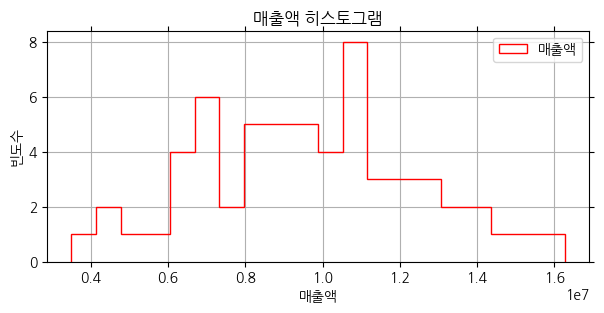

In [86]:
plt.figure(figsize= (7,3))
plt.hist(df['매출액'], bins =20, color = 'red', histtype = 'step', label = '매출액')
plt.title("매출액 히스토그램")
plt.xlabel("매출액")
plt.ylabel("빈도수")
plt.grid()
plt.tick_params( axis = 'both', direction = 'out', top = True, right = True)
plt.legend()
plt.savefig("매출액.png", dpi =300)
plt.show()


In [91]:
# boxplot

# 이상치 만들기
import numpy as np

data = np.random.randint(50,100,100)
outlier = np.array([150, 10, 20])

data_all = np.concatenate([data, outlier])



(103,)

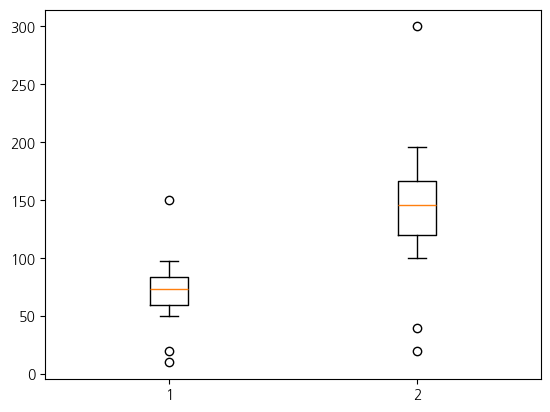

In [95]:
# boxplot

plt.boxplot(data_all,  positions= [1])
plt.boxplot(data_all*2, positions = [2])
plt.show()